# Pitch-based EDA for IEMOCAP Dataset

이 노트북은 IEMOCAP 데이터셋에 대한 pitch 단위 탐색적 데이터 분석(EDA)을 수행합니다.

## 분석 내용:
- 감정별 pitch 통계 (평균, 표준편차, 최소/최대값)
- 감정별 pitch 분포 시각화
- Pitch 범위 및 변동성 분석
- Pitch contour 시각화
- 감정별 비교 분석

In [1]:
# 필요한 라이브러리 임포트
import sys
sys.path.append('./src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import librosa
import librosa.display
from datasets import load_dataset, Audio
import warnings
warnings.filterwarnings('ignore')

from config import SAMPLE_RATE, EMOTIONS, ID2EMOTION

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


## 1. 데이터셋 로드

In [2]:
import sys
import os
import torch
import numpy as np
from transformers import RobertaTokenizer
from datasets import load_dataset, Audio
import soundfile as sf
import io
from tqdm.auto import tqdm

# 경로 설정 및 임포트
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

try:
    from src.model import MultimodalEmotionModel
    from src.config import SAMPLE_RATE, MAX_AUDIO_LEN, MAX_TEXT_LEN, EMOTIONS
except ImportError:
    # src 경로가 안 잡힐 경우를 대비해 현재 디렉토리 기준 추가
    sys.path.append(os.path.abspath("src"))
    from src.model import MultimodalEmotionModel
    from src.config import SAMPLE_RATE, MAX_AUDIO_LEN, MAX_TEXT_LEN, EMOTIONS

# 디바이스 설정
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# 학습된 모델 로드
print("모델 로딩 중...")

# ⚠️ MPS 버그 해결: CPU에서 먼저 로드한 후 MPS로 이동
model = MultimodalEmotionModel(num_classes=4)
checkpoint = torch.load('../models/best_model.pt', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
print("✅ 모델 state_dict 로드 완료 (CPU)")

model.to(device)
model.eval()
print(f"✅ 모델을 {device}로 이동 완료!")
print(f"   Epoch {checkpoint.get('epoch', 'N/A')}, Acc: {checkpoint.get('val_acc', 'N/A')}")

# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# 데이터셋 로드 - 오디오 디코딩 완전 우회
print("\n데이터셋 로딩 중...")
print("Loading IEMOCAP dataset (without audio decoding)...")
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")

# ✅ 핵심: 오디오 디코딩 끄기 (torchcodec 회피)
ds = ds.cast_column("audio", Audio(decode=False))

# 메타데이터만 사용해서 필터링
target_emotions = ['angry', 'sad', 'happy', 'excited', 'neutral']
print("Filtering by emotion...")

filtered_indices = []
for idx, example in enumerate(tqdm(ds, desc="Filtering")):
    if example['major_emotion'] in target_emotions:
        filtered_indices.append(idx)

ds = ds.select(filtered_indices)
print(f"Filtered to {len(ds)} samples")

# 레이블 매핑
def map_label(example):
    emo = example['major_emotion']
    if emo == 'angry':
        label = EMOTIONS['ang']
    elif emo == 'sad':
        label = EMOTIONS['sad']
    elif emo in ['happy', 'excited']:
        label = EMOTIONS['hap']
    elif emo == 'neutral':
        label = EMOTIONS['neu']
    else:
        label = -1
    return {'label': label}

ds = ds.map(map_label)

# Train/Val split
ds = ds.train_test_split(test_size=0.2, seed=42)
dataset_raw = ds['train']

print(f"총 샘플 수: {len(dataset_raw)}")

# Custom Dataset Wrapper
class SimpleDatasetWrapper:
    def __init__(self, hf_dataset):
        self.ds = hf_dataset
        self.tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        sample = self.ds[idx]
        
        # 🔥 오디오 디코딩을 여기서 직접 수행 (soundfile 사용)
        audio_bytes = sample['audio']['bytes']
        audio_array, sr = sf.read(io.BytesIO(audio_bytes))
        
        # Resample if needed
        if sr != SAMPLE_RATE:
            pass # 간단한 처리
            
        # Pad/Truncate
        max_len = int(SAMPLE_RATE * MAX_AUDIO_LEN)
        if len(audio_array) > max_len:
            audio_array = audio_array[:max_len]
        else:
            audio_array = np.pad(audio_array, (0, max_len - len(audio_array)), 'constant')
        
        # Normalize
        max_val = np.max(np.abs(audio_array))
        if max_val > 0:
            audio_array = audio_array / max_val
            
        # Text
        text = sample['transcription']
        encoding = self.tokenizer(
            text,
            max_length=MAX_TEXT_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Audio mask
        audio_mask = np.zeros(len(audio_array), dtype=np.int32)
        # 실제로는 디코딩된 길이를 사용
        decoded_len = len(sf.read(io.BytesIO(sample['audio']['bytes']))[0])
        if decoded_len > max_len:
            decoded_len = max_len
        audio_mask[:decoded_len] = 1
        
        return {
            'audio': torch.tensor(audio_array, dtype=torch.float32),
            'audio_mask': torch.tensor(audio_mask, dtype=torch.long),
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(sample['label'], dtype=torch.long)
        }

dataset = SimpleDatasetWrapper(dataset_raw)
print(f"✅ Dataset wrapper 생성 완료!")

Using device: mps
모델 로딩 중...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 state_dict 로드 완료 (CPU)
✅ 모델을 mps로 이동 완료!
   Epoch 2, Acc: 0.6606104651162791

데이터셋 로딩 중...
Loading IEMOCAP dataset (without audio decoding)...
Filtering by emotion...


Filtering:   0%|          | 0/10039 [00:00<?, ?it/s]

Filtered to 6877 samples
총 샘플 수: 5501
✅ Dataset wrapper 생성 완료!


## 2. Pitch 추출 함수 정의

In [3]:
def extract_pitch(audio_array, sr=SAMPLE_RATE):
    """
    librosa를 사용하여 오디오에서 pitch(F0)를 추출합니다.
    
    Args:
        audio_array: 오디오 신호 배열
        sr: 샘플링 레이트
    
    Returns:
        pitch_values: 추출된 pitch 값 (Hz)
        pitch_stats: pitch 통계 (mean, std, min, max, median)
    """
    # piptrack을 사용한 pitch 추출
    pitches, magnitudes = librosa.piptrack(y=audio_array, sr=sr, 
                                           fmin=75, fmax=600,
                                           threshold=0.1)
    
    # 각 프레임에서 가장 강한 pitch 선택
    pitch_values = []
    for i in range(pitches.shape[1]):
        index = magnitudes[:, i].argmax()
        pitch = pitches[index, i]
        if pitch > 0:  # 유효한 pitch만 저장
            pitch_values.append(pitch)
    
    pitch_values = np.array(pitch_values)
    
    # 통계 계산
    if len(pitch_values) > 0:
        pitch_stats = {
            'mean': np.mean(pitch_values),
            'std': np.std(pitch_values),
            'min': np.min(pitch_values),
            'max': np.max(pitch_values),
            'median': np.median(pitch_values),
            'range': np.max(pitch_values) - np.min(pitch_values),
            'q25': np.percentile(pitch_values, 25),
            'q75': np.percentile(pitch_values, 75)
        }
    else:
        pitch_stats = {
            'mean': 0, 'std': 0, 'min': 0, 'max': 0, 
            'median': 0, 'range': 0, 'q25': 0, 'q75': 0
        }
    
    return pitch_values, pitch_stats

print("Pitch 추출 함수 정의 완료!")

Pitch 추출 함수 정의 완료!


## 3. 전체 데이터셋에 대한 Pitch 추출

In [4]:
# Pitch 데이터 추출 (샘플링: 전체 데이터셋이 크면 일부만)
# 전체 분석을 원하면 max_samples를 None으로 설정
max_samples = 500  # None으로 설정하면 전체 데이터 분석

pitch_data = []

# ⚠️ 수정: ds 대신 dataset_raw 사용 (ds는 DatasetDict임)
target_dataset = dataset_raw 
num_samples = len(target_dataset) if max_samples is None else min(max_samples, len(target_dataset))
print(f"{num_samples}개 샘플에 대해 pitch 추출 중...")

# soundfile 임포트 확인
import soundfile as sf
import io

for idx in tqdm(range(num_samples)):
    sample = target_dataset[idx]
    
    # ⚠️ 수정: 오디오 디코딩 직접 수행
    audio_bytes = sample['audio']['bytes']
    audio_array, sr = sf.read(io.BytesIO(audio_bytes))
    
    # label_name이 없는 경우 처리 (map_label 함수에서 label만 만들었을 수 있음)
    # 역매핑 필요
    label_id = sample['label']
    id2emotion = {v: k for k, v in EMOTIONS.items()}
    label_name = id2emotion.get(label_id, 'unknown')
    
    try:
        pitch_values, pitch_stats = extract_pitch(audio_array)
        
        if pitch_stats['mean'] > 0:  # 유효한 pitch가 있는 경우만 저장
            pitch_data.append({
                'sample_idx': idx,
                'emotion': label_name,
                'pitch_mean': pitch_stats['mean'],
                'pitch_std': pitch_stats['std'],
                'pitch_min': pitch_stats['min'],
                'pitch_max': pitch_stats['max'],
                'pitch_median': pitch_stats['median'],
                'pitch_range': pitch_stats['range'],
                'pitch_q25': pitch_stats['q25'],
                'pitch_q75': pitch_stats['q75'],
                'pitch_values': pitch_values
            })
    except Exception as e:
        print(f"샘플 {idx} 처리 중 오류: {e}")
        continue

# DataFrame 생성
import pandas as pd
df_pitch = pd.DataFrame([{k: v for k, v in item.items() if k != 'pitch_values'} 
                         for item in pitch_data])

print(f"\n총 {len(df_pitch)}개 샘플의 pitch 데이터 추출 완료!")
print(f"\n감정별 샘플 수:")
print(df_pitch['emotion'].value_counts())

500개 샘플에 대해 pitch 추출 중...


  0%|          | 0/500 [00:00<?, ?it/s]


총 500개 샘플의 pitch 데이터 추출 완료!

감정별 샘플 수:
emotion
hap    185
neu    138
ang     90
sad     87
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. 폰트 설정 (AppleGothic 추천)
# Mac 시스템에 기본적으로 설치되어 있는 폰트입니다.
plt.rc('font', family='AppleGothic')

# 2. 마이너스 부호 깨짐 방지
# 폰트를 한글로 변경하면 마이너스 부호(-)가 네모로 깨질 수 있어, 이를 명시적으로 막아줍니다.
mpl.rcParams['axes.unicode_minus'] = False

print("Matplotlib 폰트 설정 완료: AppleGothic")

Matplotlib 폰트 설정 완료: AppleGothic


## 4. 감정별 Pitch 통계 분석

In [6]:
# 감정별 통계
print("="*80)
print("감정별 Pitch 통계")
print("="*80)

emotion_stats = df_pitch.groupby('emotion').agg({
    'pitch_mean': ['mean', 'std'],
    'pitch_std': ['mean', 'std'],
    'pitch_min': 'mean',
    'pitch_max': 'mean',
    'pitch_median': 'mean',
    'pitch_range': ['mean', 'std']
}).round(2)

print(emotion_stats)
print("\n")

# 더 자세한 통계를 위한 describe
for emotion in df_pitch['emotion'].unique():
    print(f"\n{'='*60}")
    print(f"감정: {emotion}")
    print(f"{'='*60}")
    emotion_df = df_pitch[df_pitch['emotion'] == emotion]
    print(emotion_df[['pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_range']].describe())

감정별 Pitch 통계
        pitch_mean        pitch_std        pitch_min pitch_max pitch_median  \
              mean    std      mean    std      mean      mean         mean   
emotion                                                                       
ang         291.31  56.91    125.31  21.72     93.75    581.82       266.55   
hap         282.13  55.55    127.98  22.84     87.51    572.32       256.38   
neu         253.00  47.12    124.36  28.69     83.74    558.51       219.36   
sad         215.37  42.37    100.03  26.97     78.16    528.04       198.89   

        pitch_range          
               mean     std  
emotion                      
ang          488.08   37.52  
hap          484.81   42.74  
neu          474.78   64.52  
sad          449.88  104.62  



감정: neu
       pitch_mean   pitch_std   pitch_min   pitch_max  pitch_range
count  138.000000  138.000000  138.000000  138.000000   138.000000
mean   252.997828  124.360242   83.736421  558.514917   474.778496
std     47.

## 5. Pitch 분포 시각화

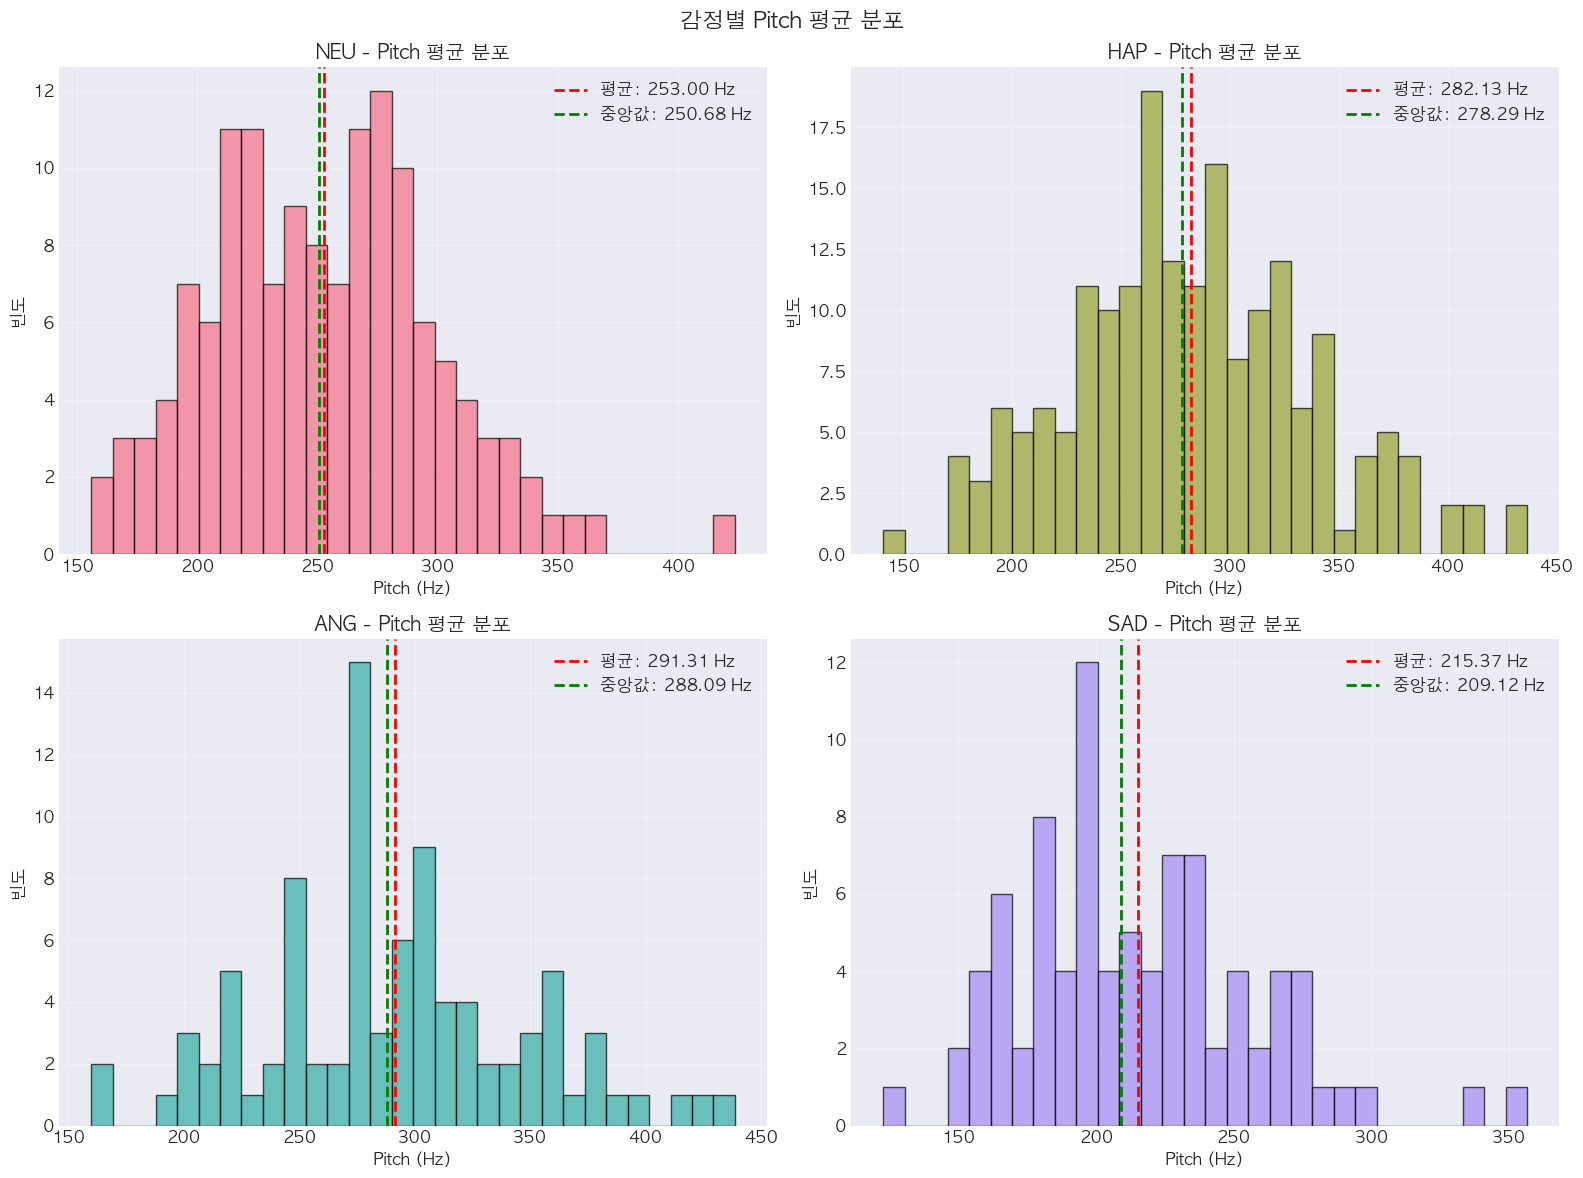

In [7]:
# 5.1 감정별 평균 Pitch 분포
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('감정별 Pitch 평균 분포', fontsize=16, fontweight='bold')

emotions = df_pitch['emotion'].unique()
colors = sns.color_palette("husl", len(emotions))

for idx, emotion in enumerate(emotions):
    ax = axes[idx // 2, idx % 2]
    emotion_data = df_pitch[df_pitch['emotion'] == emotion]['pitch_mean']
    
    ax.hist(emotion_data, bins=30, alpha=0.7, color=colors[idx], edgecolor='black')
    ax.axvline(emotion_data.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'평균: {emotion_data.mean():.2f} Hz')
    ax.axvline(emotion_data.median(), color='green', linestyle='--', linewidth=2,
               label=f'중앙값: {emotion_data.median():.2f} Hz')
    
    ax.set_xlabel('Pitch (Hz)', fontsize=12)
    ax.set_ylabel('빈도', fontsize=12)
    ax.set_title(f'{emotion.upper()} - Pitch 평균 분포', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

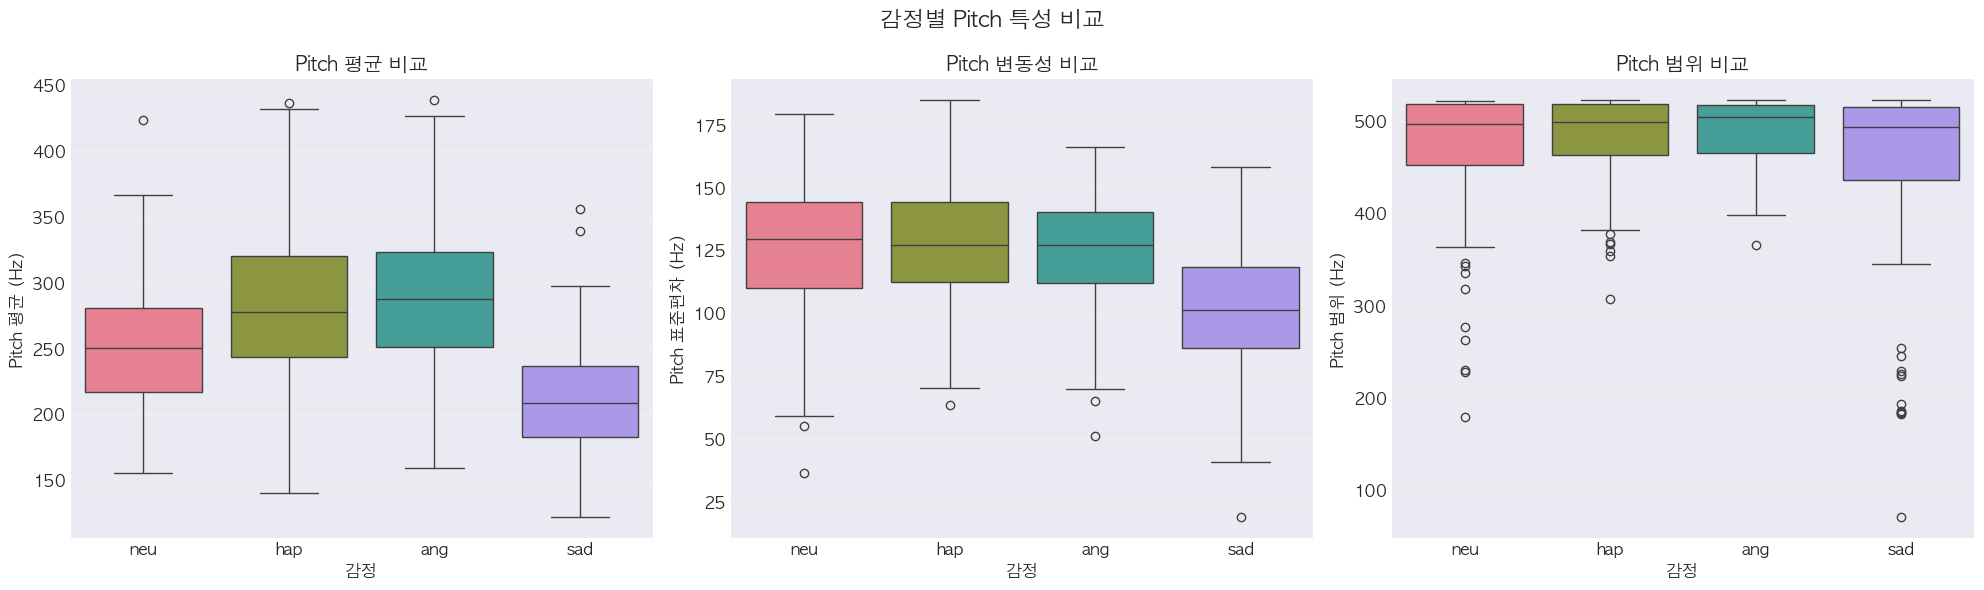

In [8]:
# 5.2 감정별 Pitch 비교 (Box Plot)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('감정별 Pitch 특성 비교', fontsize=16, fontweight='bold')

# Pitch 평균
sns.boxplot(data=df_pitch, x='emotion', y='pitch_mean', ax=axes[0], palette='husl')
axes[0].set_title('Pitch 평균 비교', fontsize=14, fontweight='bold')
axes[0].set_xlabel('감정', fontsize=12)
axes[0].set_ylabel('Pitch 평균 (Hz)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Pitch 표준편차 (변동성)
sns.boxplot(data=df_pitch, x='emotion', y='pitch_std', ax=axes[1], palette='husl')
axes[1].set_title('Pitch 변동성 비교', fontsize=14, fontweight='bold')
axes[1].set_xlabel('감정', fontsize=12)
axes[1].set_ylabel('Pitch 표준편차 (Hz)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Pitch 범위
sns.boxplot(data=df_pitch, x='emotion', y='pitch_range', ax=axes[2], palette='husl')
axes[2].set_title('Pitch 범위 비교', fontsize=14, fontweight='bold')
axes[2].set_xlabel('감정', fontsize=12)
axes[2].set_ylabel('Pitch 범위 (Hz)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

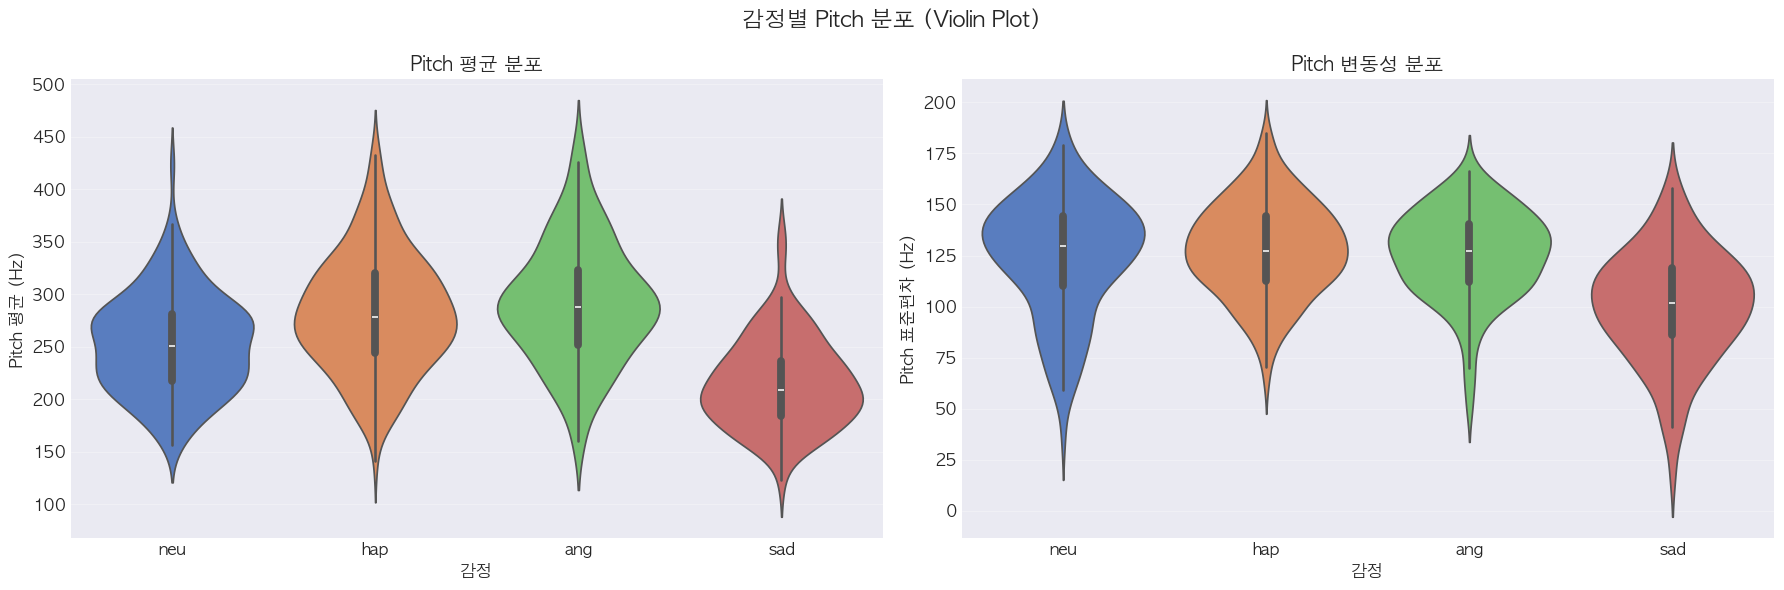

In [9]:
# 5.3 감정별 Pitch 분포 Violin Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('감정별 Pitch 분포 (Violin Plot)', fontsize=16, fontweight='bold')

# Pitch 평균
sns.violinplot(data=df_pitch, x='emotion', y='pitch_mean', ax=axes[0], palette='muted')
axes[0].set_title('Pitch 평균 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('감정', fontsize=12)
axes[0].set_ylabel('Pitch 평균 (Hz)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Pitch 표준편차
sns.violinplot(data=df_pitch, x='emotion', y='pitch_std', ax=axes[1], palette='muted')
axes[1].set_title('Pitch 변동성 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('감정', fontsize=12)
axes[1].set_ylabel('Pitch 표준편차 (Hz)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Pitch Contour 시각화 (샘플별)

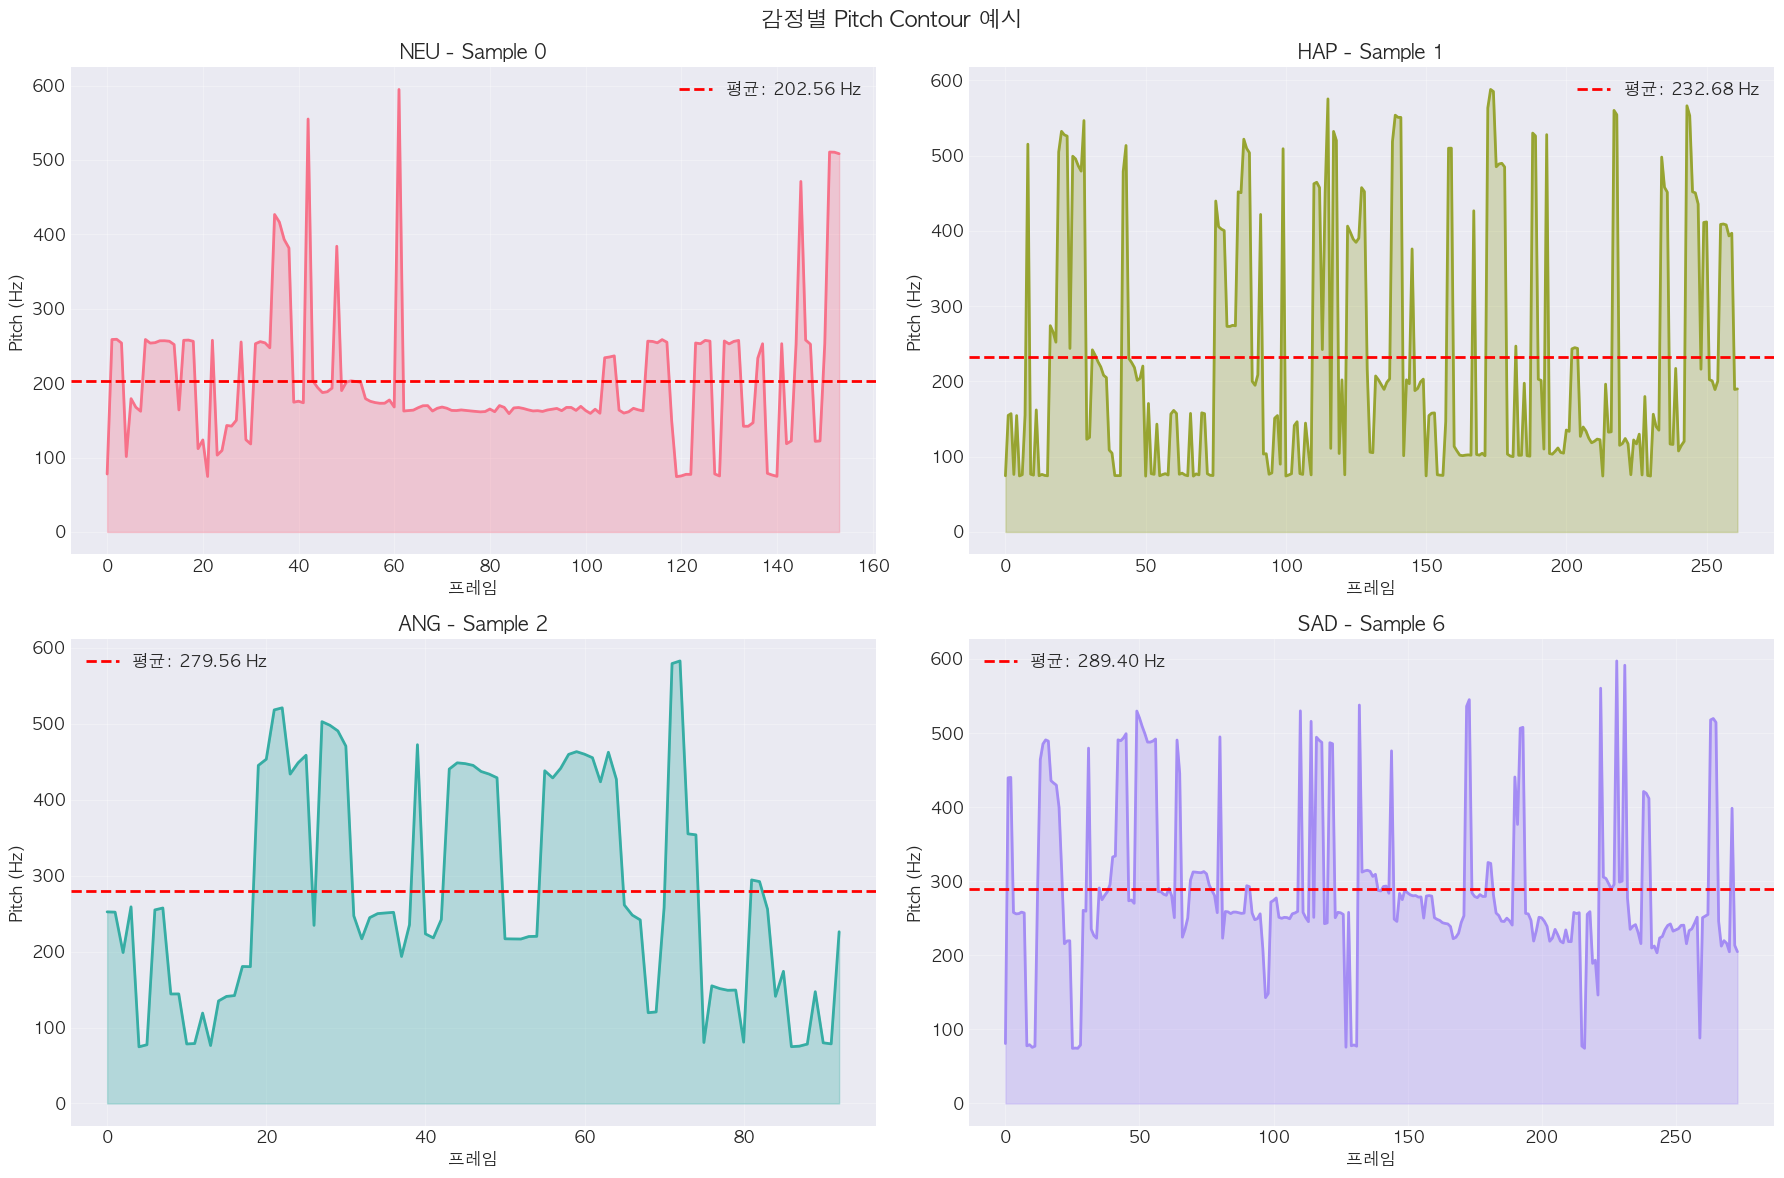

In [10]:
# 각 감정당 1개씩 샘플 선택하여 pitch contour 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('감정별 Pitch Contour 예시', fontsize=16, fontweight='bold')

for idx, emotion in enumerate(emotions):
    ax = axes[idx // 2, idx % 2]
    
    # 해당 감정의 첫 번째 샘플 선택
    emotion_samples = [item for item in pitch_data if item['emotion'] == emotion]
    if len(emotion_samples) > 0:
        sample = emotion_samples[0]
        pitch_values = sample['pitch_values']
        
        # Pitch contour 그리기
        time_axis = np.arange(len(pitch_values))
        ax.plot(time_axis, pitch_values, linewidth=2, color=colors[idx])
        ax.fill_between(time_axis, pitch_values, alpha=0.3, color=colors[idx])
        
        # 평균선
        ax.axhline(sample['pitch_mean'], color='red', linestyle='--', linewidth=2,
                   label=f'평균: {sample["pitch_mean"]:.2f} Hz')
        
        ax.set_xlabel('프레임', fontsize=12)
        ax.set_ylabel('Pitch (Hz)', fontsize=12)
        ax.set_title(f'{emotion.upper()} - Sample {sample["sample_idx"]}', 
                     fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 감정 간 Pitch 비교 (통계 검정)

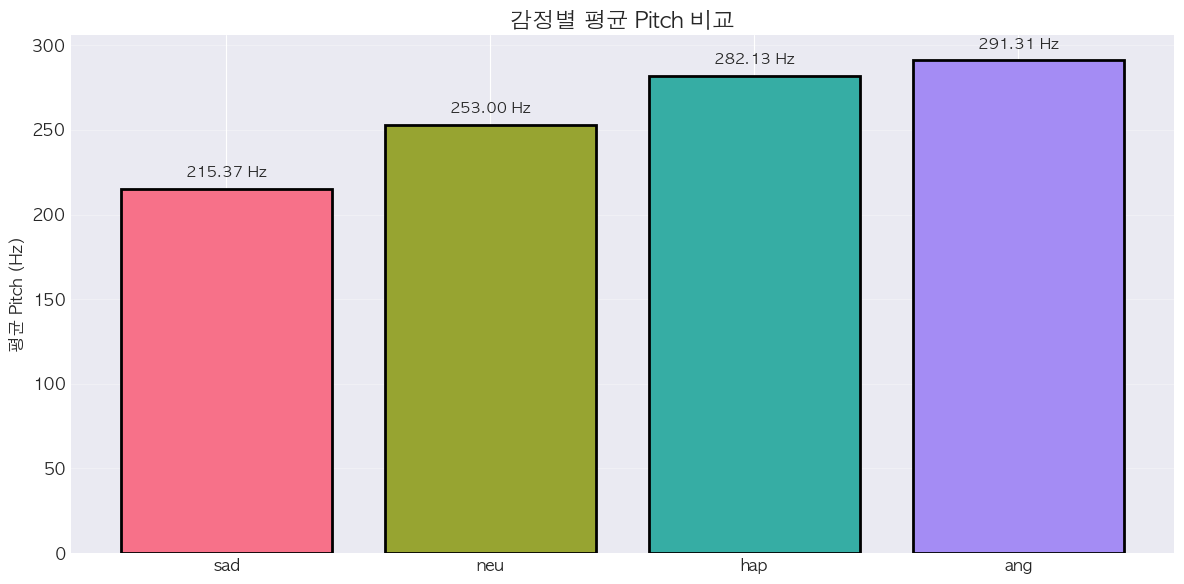

In [11]:
# 감정 간 평균 pitch 차이 시각화
emotion_means = df_pitch.groupby('emotion')['pitch_mean'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(emotion_means)), emotion_means.values, 
              color=colors, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(emotion_means)))
ax.set_xticklabels(emotion_means.index, fontsize=12)
ax.set_ylabel('평균 Pitch (Hz)', fontsize=12)
ax.set_title('감정별 평균 Pitch 비교', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 값 표시
for i, (emotion, value) in enumerate(emotion_means.items()):
    ax.text(i, value + 5, f'{value:.2f} Hz', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. 2D Scatter Plot (Pitch Mean vs Std)

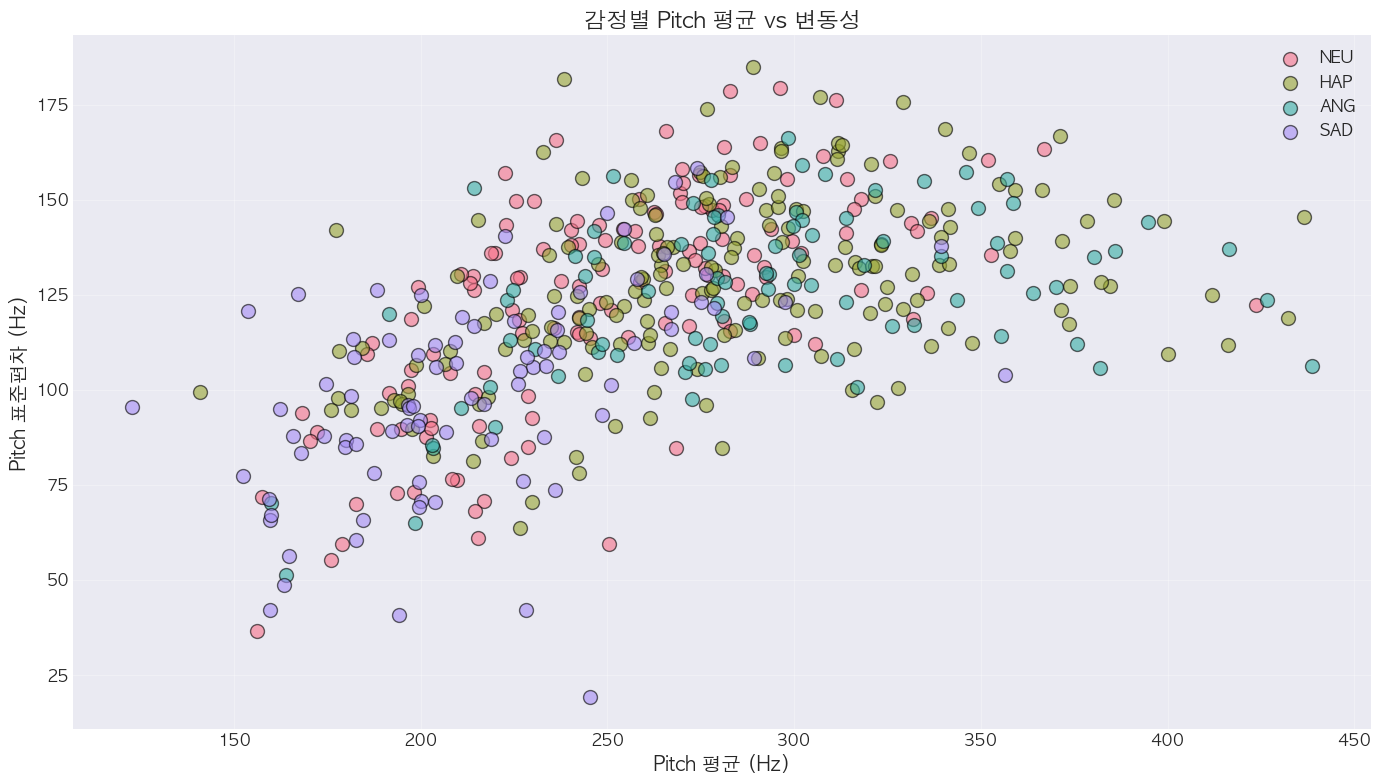

In [12]:
# Pitch 평균 vs 표준편차 산점도
fig, ax = plt.subplots(figsize=(14, 8))

for idx, emotion in enumerate(emotions):
    emotion_df = df_pitch[df_pitch['emotion'] == emotion]
    ax.scatter(emotion_df['pitch_mean'], emotion_df['pitch_std'], 
               alpha=0.6, s=100, color=colors[idx], label=emotion.upper(), 
               edgecolors='black', linewidth=1)

ax.set_xlabel('Pitch 평균 (Hz)', fontsize=14)
ax.set_ylabel('Pitch 표준편차 (Hz)', fontsize=14)
ax.set_title('감정별 Pitch 평균 vs 변동성', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Heatmap - 감정별 Pitch 특성 상관관계

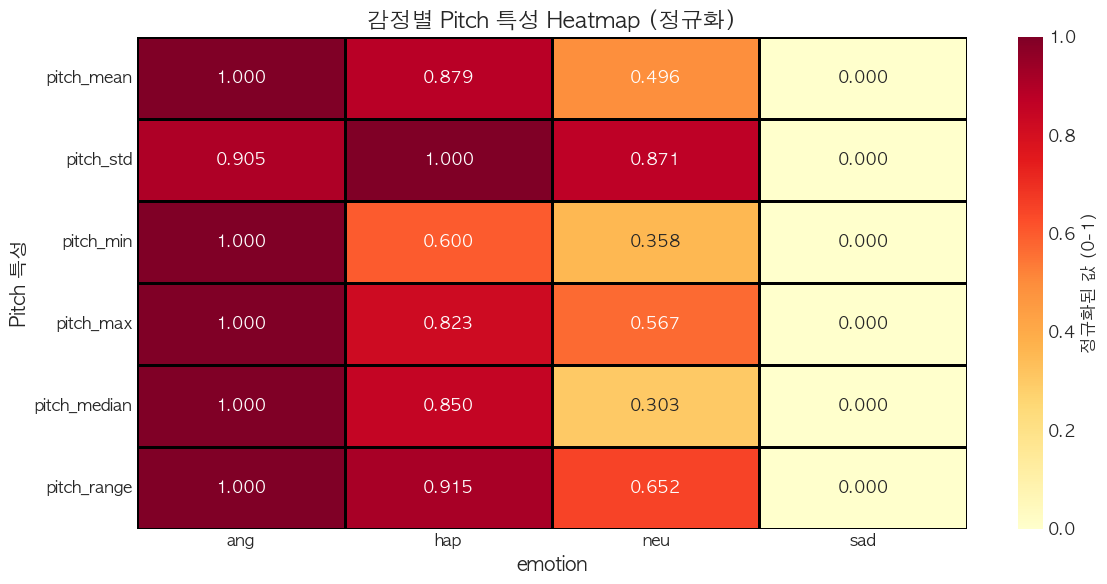

In [13]:
# 감정별 평균 pitch 특성을 heatmap으로 시각화
emotion_features = df_pitch.groupby('emotion')[[
    'pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 
    'pitch_median', 'pitch_range'
]].mean()

# 정규화 (0-1 스케일)
emotion_features_normalized = (emotion_features - emotion_features.min()) / \
                               (emotion_features.max() - emotion_features.min())

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(emotion_features_normalized.T, annot=True, fmt='.3f', 
            cmap='YlOrRd', linewidths=2, linecolor='black',
            cbar_kws={'label': '정규화된 값 (0-1)'}, ax=ax)
ax.set_xlabel('emotion', fontsize=14, fontweight='bold')
ax.set_ylabel('Pitch 특성', fontsize=14, fontweight='bold')
ax.set_title('감정별 Pitch 특성 Heatmap (정규화)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. 요약 및 인사이트

In [14]:
print("="*80)
print("Pitch 기반 EDA 요약")
print("="*80)
print()

# 1. 전체 통계
print("1. 전체 데이터셋 Pitch 통계:")
print(f"   - 평균 Pitch: {df_pitch['pitch_mean'].mean():.2f} Hz")
print(f"   - 표준편차: {df_pitch['pitch_mean'].std():.2f} Hz")
print(f"   - 최소값: {df_pitch['pitch_min'].min():.2f} Hz")
print(f"   - 최대값: {df_pitch['pitch_max'].max():.2f} Hz")
print()

# 2. 감정별 특성
print("2. 감정별 Pitch 특성:")
for emotion in emotions:
    emotion_df = df_pitch[df_pitch['emotion'] == emotion]
    print(f"\n   [{emotion.upper()}]")
    print(f"   - 평균 Pitch: {emotion_df['pitch_mean'].mean():.2f} ± {emotion_df['pitch_mean'].std():.2f} Hz")
    print(f"   - 평균 변동성: {emotion_df['pitch_std'].mean():.2f} Hz")
    print(f"   - 평균 범위: {emotion_df['pitch_range'].mean():.2f} Hz")

print()
print("="*80)
print("분석 완료!")
print("="*80)

Pitch 기반 EDA 요약

1. 전체 데이터셋 Pitch 통계:
   - 평균 Pitch: 264.13 Hz
   - 표준편차: 57.76 Hz
   - 최소값: 74.22 Hz
   - 최대값: 597.59 Hz

2. 감정별 Pitch 특성:

   [NEU]
   - 평균 Pitch: 253.00 ± 47.12 Hz
   - 평균 변동성: 124.36 Hz
   - 평균 범위: 474.78 Hz

   [HAP]
   - 평균 Pitch: 282.13 ± 55.55 Hz
   - 평균 변동성: 127.98 Hz
   - 평균 범위: 484.81 Hz

   [ANG]
   - 평균 Pitch: 291.31 ± 56.91 Hz
   - 평균 변동성: 125.31 Hz
   - 평균 범위: 488.08 Hz

   [SAD]
   - 평균 Pitch: 215.37 ± 42.37 Hz
   - 평균 변동성: 100.03 Hz
   - 평균 범위: 449.88 Hz

분석 완료!


## 11. 추가 분석: 감정별 오디오 샘플 청취 및 시각화


감정: ANG
선택된 샘플 인덱스: 2, 길이: 2.98초
오디오 재생:


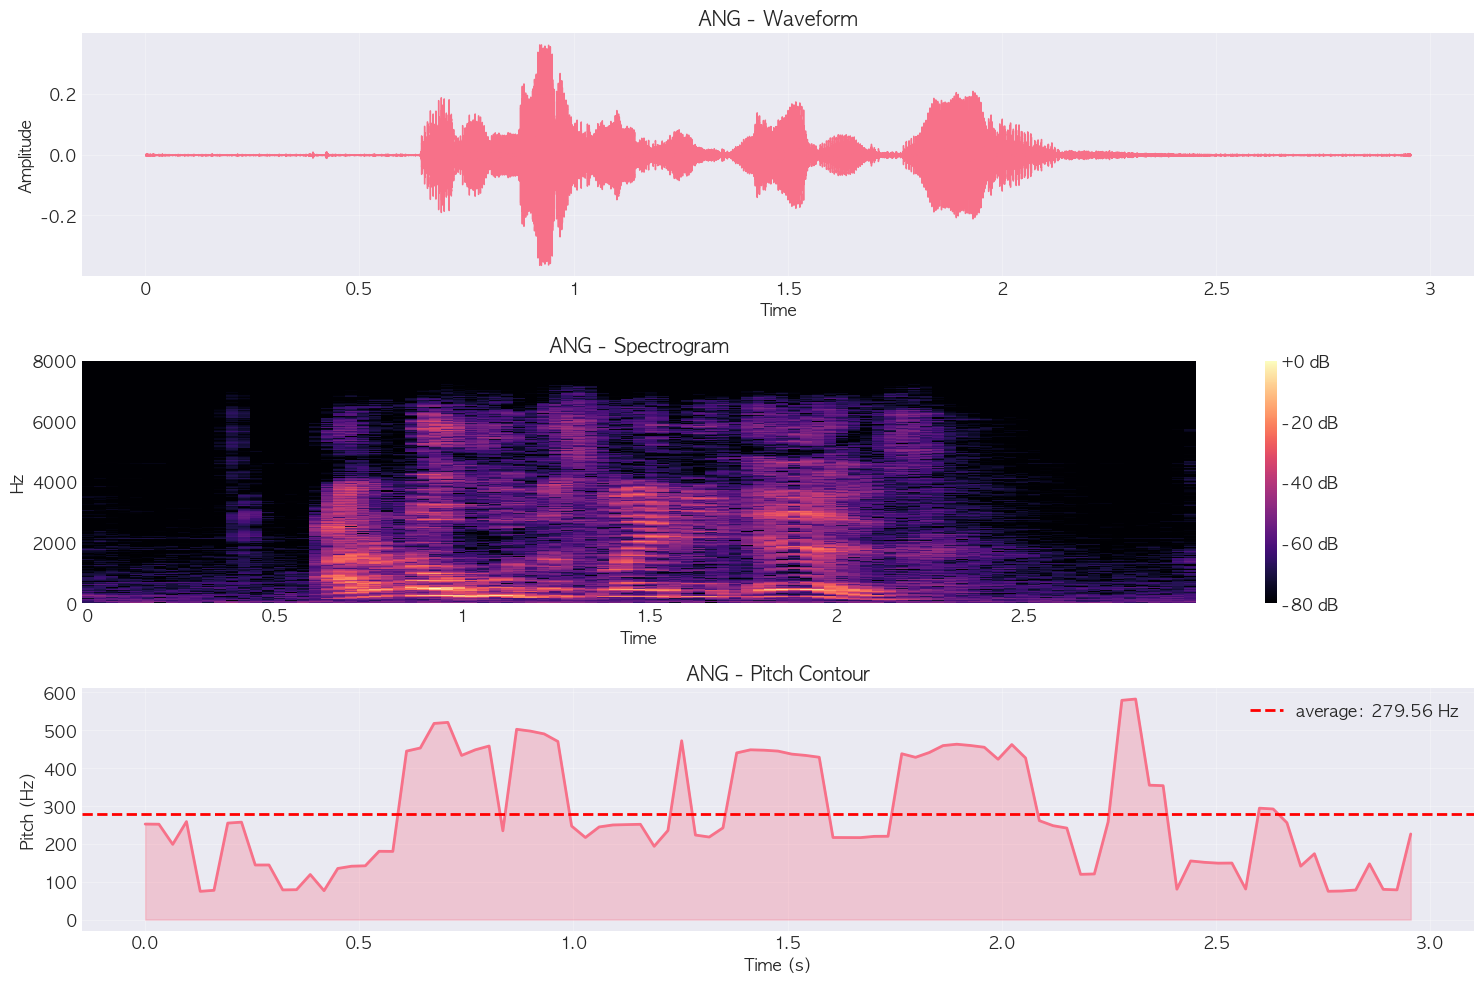


Pitch summary:
  - average: 279.56 Hz
  - std: 146.07 Hz
  - range: 508.08 Hz
  - min/max: 74.60 / 582.67 Hz

감정: SAD
선택된 샘플 인덱스: 96, 길이: 3.01초
오디오 재생:


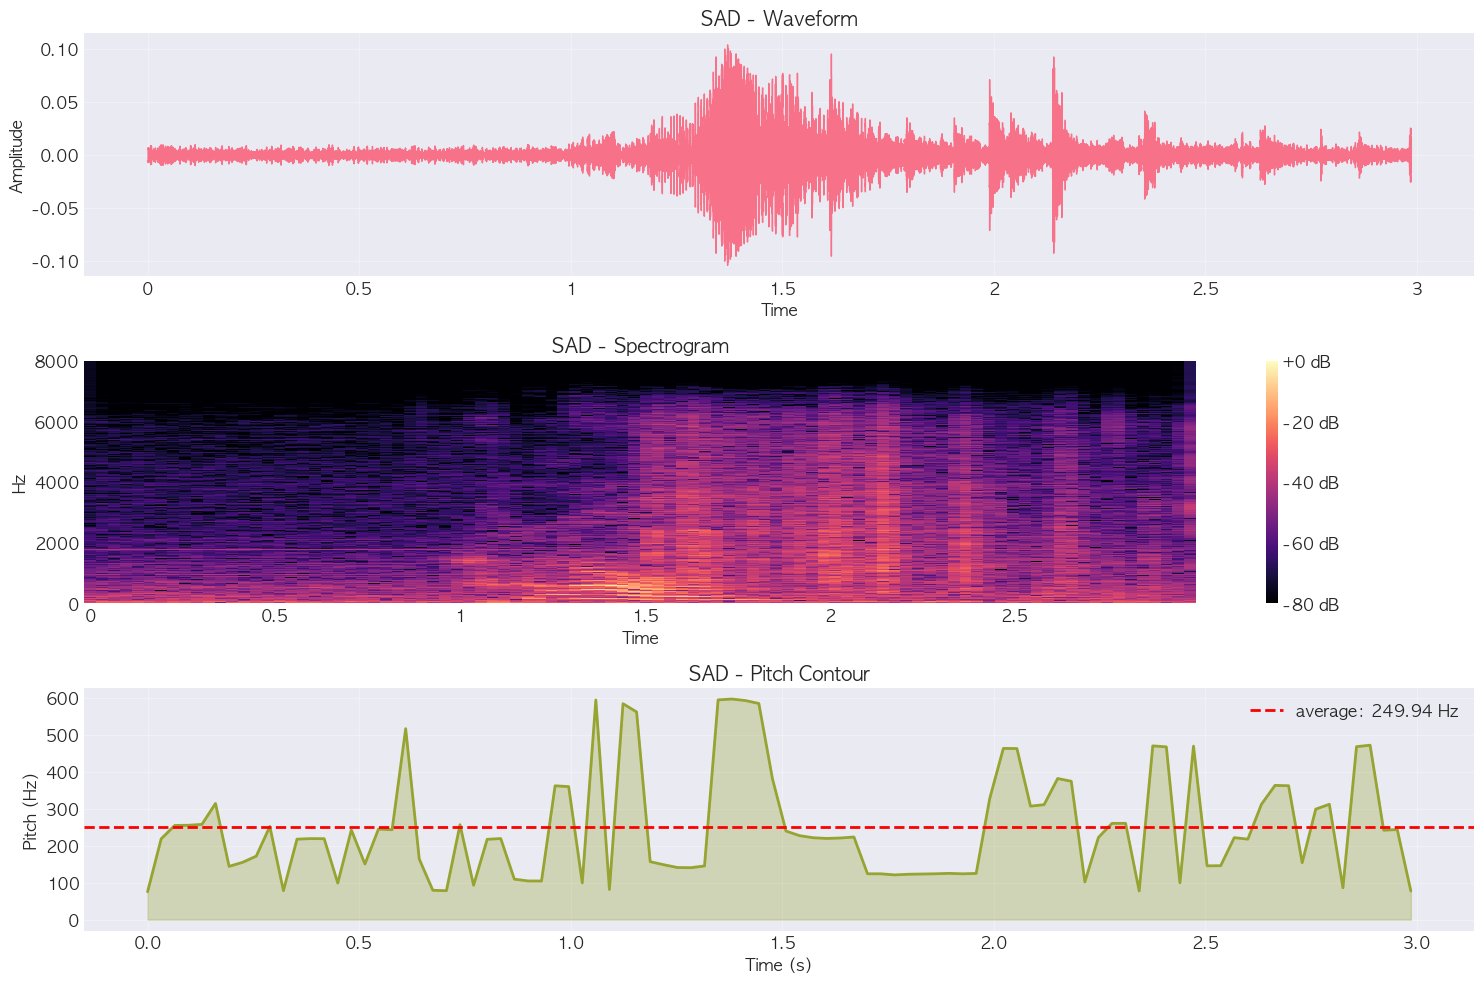


Pitch summary:
  - average: 249.94 Hz
  - std: 146.53 Hz
  - range: 521.06 Hz
  - min/max: 75.15 / 596.21 Hz

감정: HAP
선택된 샘플 인덱스: 93, 길이: 3.01초
오디오 재생:


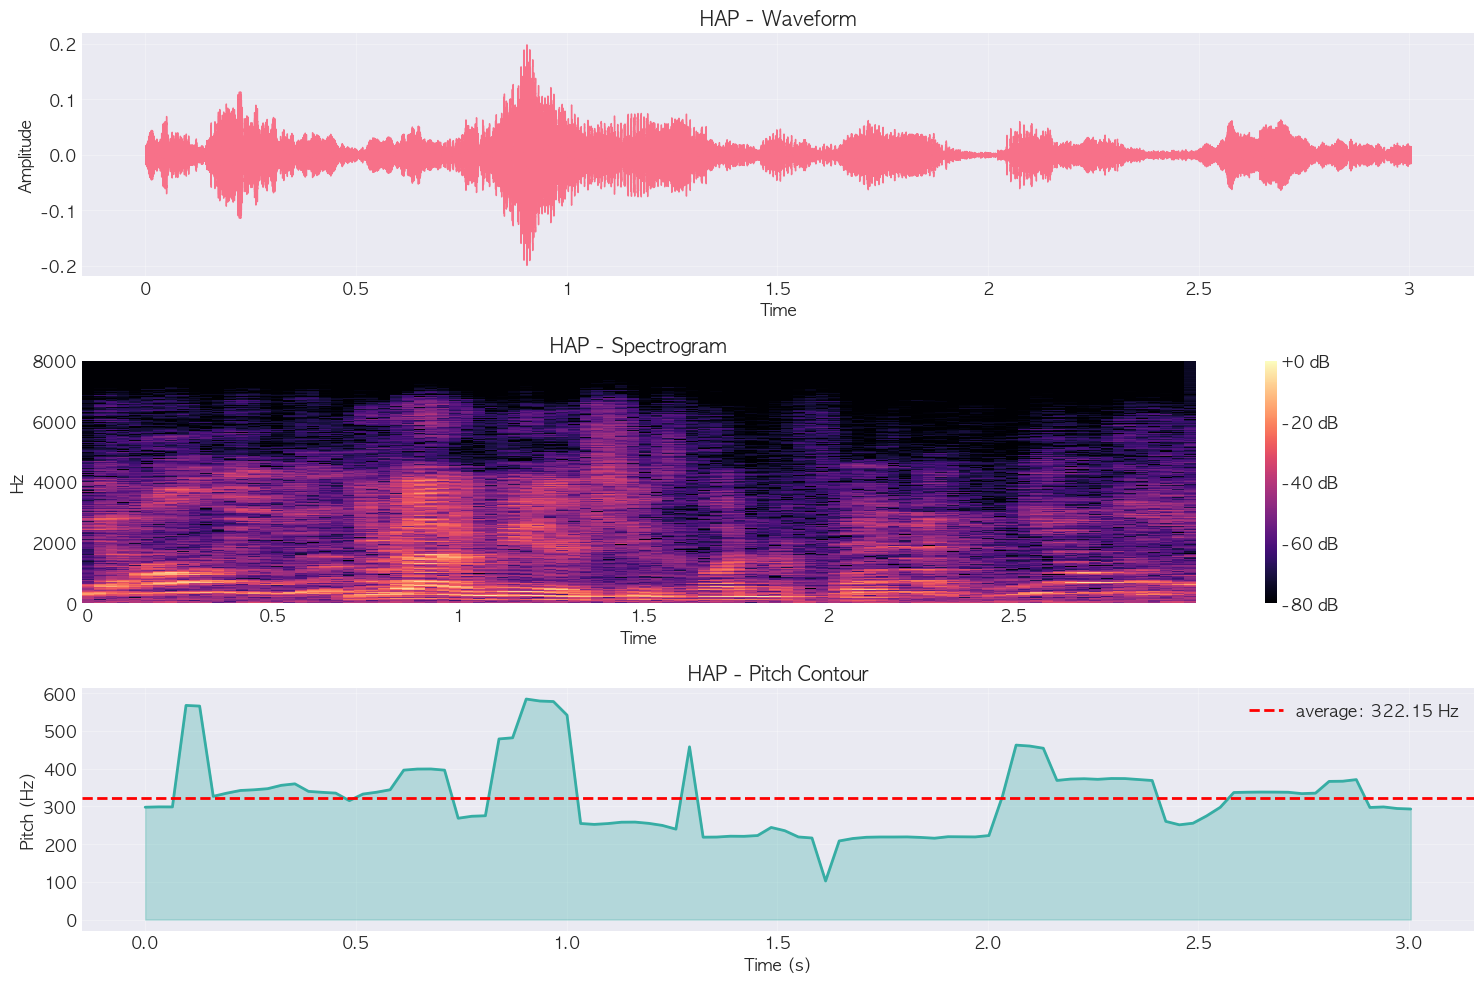


Pitch summary:
  - average: 322.15 Hz
  - std: 96.83 Hz
  - range: 481.92 Hz
  - min/max: 102.21 / 584.13 Hz

감정: NEU
선택된 샘플 인덱스: 223, 길이: 2.98초
오디오 재생:


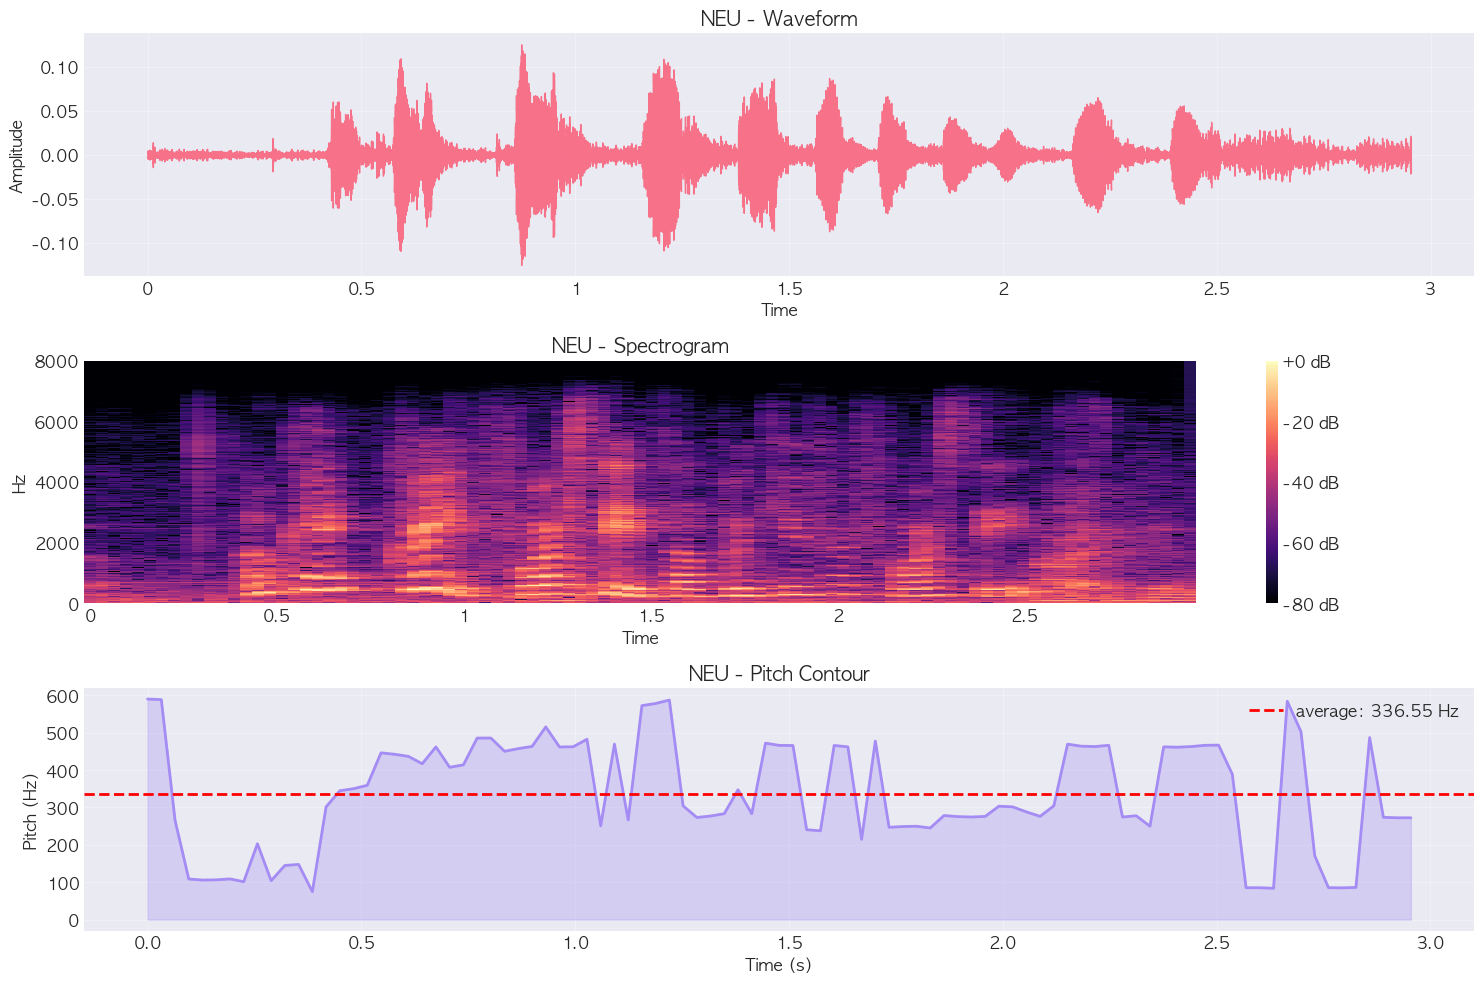


Pitch summary:
  - average: 336.55 Hz
  - std: 145.29 Hz
  - range: 515.35 Hz
  - min/max: 74.67 / 590.02 Hz


In [15]:

# IPython display를 사용하여 오디오 재생 및 스펙트로그램 시각화
from IPython.display import Audio as IPAudio
import librosa.display
import soundfile as sf
import io

# 3초 길이의 샘플을 찾기 위한 설정
target_duration = 3.0
tolerance = 0.5 # 여유 범위
target_emotions = ['ang', 'sad', 'hap', 'neu']
colors = sns.color_palette("husl", len(target_emotions))

# 각 감정당 3초 길이의 샘플 선택
for i, emotion in enumerate(target_emotions):
    print(f"\n{'='*60}")
    print(f"감정: {emotion.upper()}")
    print(f"{'='*60}")
    
    # 해당 감정의 3초 길이 샘플 찾기
    emotion_sample = None
    min_diff = float('inf')
    
    for item in pitch_data:
        if item['emotion'] == emotion:
            # 길이 계산 (hop_length 고려)
            duration = len(item['pitch_values']) * 512 / SAMPLE_RATE
            diff = abs(duration - target_duration)
            
            if diff < tolerance and diff < min_diff:
                min_diff = diff
                emotion_sample = item
    
    if emotion_sample is None:
        print(f"해당 감정({emotion})의 3초 샘플을 찾을 수 없습니다.")
        continue
    
    sample_idx = emotion_sample['sample_idx']
    print(f"선택된 샘플 인덱스: {sample_idx}, 길이: {len(emotion_sample['pitch_values']) * 512 / SAMPLE_RATE:.2f}초")
    
    # ⚠️ 수정: ds 대신 dataset_raw 사용
    sample = dataset_raw[sample_idx]
    
    # ⚠️ 수정: 오디오 디코딩 직접 수행
    audio_bytes = sample['audio']['bytes']
    audio_array, sr = sf.read(io.BytesIO(audio_bytes))
    
    # 오디오 재생
    print("오디오 재생:")
    display(IPAudio(audio_array, rate=SAMPLE_RATE))
    
    # 시각화
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    
    # 1. 파형
    librosa.display.waveshow(audio_array, sr=SAMPLE_RATE, ax=axes[0])
    axes[0].set_title(f'{emotion.upper()} - Waveform', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    # 2. 스펙트로그램
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_array)), ref=np.max)
    img = librosa.display.specshow(D, sr=SAMPLE_RATE, x_axis='time', y_axis='hz', ax=axes[1])
    axes[1].set_title(f'{emotion.upper()} - Spectrogram', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Hz')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    # 3. Pitch contour
    pitch_values = emotion_sample['pitch_values']
    # Time axis creation
    time_axis = np.linspace(0, len(audio_array) / SAMPLE_RATE, len(pitch_values))
    
    axes[2].plot(time_axis, pitch_values, linewidth=2, color=colors[i])
    axes[2].fill_between(time_axis, pitch_values, alpha=0.3, color=colors[i])
    axes[2].axhline(emotion_sample['pitch_mean'], color='red', linestyle='--', linewidth=2,
                    label=f'average: {emotion_sample["pitch_mean"]:.2f} Hz')
    axes[2].set_title(f'{emotion.upper()} - Pitch Contour', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Pitch (Hz)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 통계 출력
    print(f"\nPitch summary:")
    print(f"  - average: {emotion_sample['pitch_mean']:.2f} Hz")
    print(f"  - std: {emotion_sample['pitch_std']:.2f} Hz")
    print(f"  - range: {emotion_sample['pitch_range']:.2f} Hz")
    print(f"  - min/max: {emotion_sample['pitch_min']:.2f} / {emotion_sample['pitch_max']:.2f} Hz")


In [ ]:
# 학습된 모델 로드
print("모델 로딩 중...")

# ⚠️ MPS 버그 해결: CPU에서 먼저 로드한 후 MPS로 이동
model = MultimodalEmotionModel(num_classes=4)
checkpoint = torch.load('../models/best_model.pt', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
print("✅ 모델 state_dict 로드 완료 (CPU)")

model.to(device)
model.eval()
print(f"✅ 모델을 {device}로 이동 완료!")
print(f"   Epoch {checkpoint.get('epoch', 'N/A')}, Acc: {checkpoint.get('val_acc', 'N/A')}")

# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# 데이터셋 로드 - 오디오 디코딩 완전 우회
print("\n데이터셋 로딩 중...")
from datasets import load_dataset
import soundfile as sf
import io

print("Loading IEMOCAP dataset (without audio decoding)...")
# decode=False로 오디오를 바이트로만 로드
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")

# 메타데이터만 사용해서 필터링 (오디오 디코딩 없음)
target_emotions = ['angry', 'sad', 'happy', 'excited', 'neutral']
print("Filtering by emotion...")

filtered_data = []
for idx in tqdm(range(len(ds)), desc="Filtering"):
    example = ds[idx]
    if example['major_emotion'] in target_emotions:
        # 레이블 매핑
        emo = example['major_emotion']
        if emo == 'angry':
            label = EMOTIONS['ang']
        elif emo == 'sad':
            label = EMOTIONS['sad']
        elif emo in ['happy', 'excited']:
            label = EMOTIONS['hap']
        elif emo == 'neutral':
            label = EMOTIONS['neu']
        else:
            continue
        
        filtered_data.append({
            'audio_bytes': example['audio']['bytes'],  # 바이트만 저장
            'path': example.get('file', ''),
            'transcription': example['transcription'],
            'label': label
        })

print(f"Filtered to {len(filtered_data)} samples")

# Train/val split
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(filtered_data, test_size=0.2, random_state=42)
print(f"Train: {len(train_data)}, Val: {len(val_data)}")

# Custom Dataset
class IEMOCAPDatasetCustom:
    def __init__(self, data_list):
        self.data = data_list
        self.tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        
        # 🔥 오디오 디코딩을 여기서만 수행 (soundfile 사용)
        audio_bytes = sample['audio_bytes']
        audio_array, sr = sf.read(io.BytesIO(audio_bytes))
        
        # Resample if needed
        if sr != SAMPLE_RATE:
            from scipy import signal
            num_samples = int(len(audio_array) * SAMPLE_RATE / sr)
            audio_array = signal.resample(audio_array, num_samples)
        
        # Pad/Truncate
        max_len = SAMPLE_RATE * MAX_AUDIO_LEN
        if len(audio_array) > max_len:
            audio_array = audio_array[:max_len]
        else:
            audio_array = np.pad(audio_array, (0, max_len - len(audio_array)), 'constant')
        
        # Normalize
        max_val = np.max(np.abs(audio_array))
        if max_val > 0:
            audio_array = audio_array / max_val
            
        # Text
        text = sample['transcription']
        encoding = self.tokenizer(
            text,
            max_length=MAX_TEXT_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Audio mask
        audio_mask = np.ones(len(audio_array), dtype=np.int32)
        
        return {
            'audio': torch.tensor(audio_array, dtype=torch.float32),
            'audio_mask': torch.tensor(audio_mask, dtype=torch.long),
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(sample['label'], dtype=torch.long)
        }

dataset = IEMOCAPDatasetCustom(train_data)
print(f"✅ 총 샘플 수: {len(dataset)}")

모델 로딩 중...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 state_dict 로드 완료 (CPU)
✅ 모델을 mps로 이동 완료!
   Epoch 2, Acc: 0.6606104651162791

데이터셋 로딩 중...
Loading IEMOCAP dataset (without audio decoding)...
Filtering by emotion...


Filtering:   0%|          | 0/10039 [00:00<?, ?it/s]

ImportError: To support decoding audio data, please install 'torchcodec'.

## 12. 데이터 저장 (선택사항)

In [33]:
# Pitch 데이터를 CSV로 저장
output_path = '../results/pitch_analysis.csv'
df_pitch.to_csv(output_path, index=False)
print(f"Pitch 분석 결과가 {output_path}에 저장되었습니다.")

Pitch 분석 결과가 ../results/pitch_analysis.csv에 저장되었습니다.
